In [ ]:
#| default_exp training

## Load Data

In [ ]:
import gzip, pickle
from pathlib import Path
from torch import tensor

In [ ]:
p_data = Path('data')
p_gz = p_data/'mnist.pkl.gz'
with gzip.open(p_gz, 'rb') as f: ((trn_x, trn_y), (vld_x, vld_y), _) = pickle.load(f, encoding='latin-1')
trn_x, trn_y, vld_x, vld_y = map(tensor, [trn_x, trn_y, vld_x, vld_y])


## Basic Model

In [ ]:
n, m = trn_x.shape
c = trn_y.max()+1
n, m, c

(50000, 784, tensor(10))

In [ ]:
nh = 50

In [ ]:
from torch import nn

In [ ]:
class Model(nn.Module):
  def __init__(self, n_inps, nh, n_outs):
    super().__init__()
    self.layers = [nn.Linear(n_inps, nh), nn.ReLU(), nn.Linear(nh, n_outs)]

  def __call__(self, x):
    for l in self.layers: x = l(x)
    return x

In [ ]:
#| export
import torch

torch.Size([50000, 10])

In [ ]:
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
model = Model(m, nh, c)
preds = model(trn_x); preds.shape

### Loss

In [ ]:
def log_softmax(x): return (x.exp()/(x.exp().sum(-1, keepdim=True))).log()

In [ ]:
log_softmax(preds)

tensor([[-2.25, -2.25, -2.25,  ..., -2.42, -2.26, -2.25],
        [-2.32, -2.41, -2.20,  ..., -2.35, -2.32, -2.19],
        [-2.30, -2.30, -2.25,  ..., -2.40, -2.35, -2.22],
        ...,
        [-2.29, -2.41, -2.24,  ..., -2.35, -2.39, -2.18],
        [-2.30, -2.37, -2.27,  ..., -2.36, -2.21, -2.22],
        [-2.25, -2.35, -2.24,  ..., -2.43, -2.31, -2.28]], grad_fn=<LogBackward0>)

In [ ]:
log_softmax(preds).shape

torch.Size([50000, 10])

The logarithmic softmax computation above can be simplified by the following rule: $\lg(\frac{a}{b}) = \lg(a) - \lg(b)$.



In [ ]:
def log_softmax(x): return x.exp().log() - x.exp().sum(-1, keepdim=True).log()

In [ ]:
log_softmax(preds)

tensor([[-2.25, -2.25, -2.25,  ..., -2.42, -2.26, -2.25],
        [-2.32, -2.41, -2.20,  ..., -2.35, -2.32, -2.19],
        [-2.30, -2.30, -2.25,  ..., -2.40, -2.35, -2.22],
        ...,
        [-2.29, -2.41, -2.24,  ..., -2.35, -2.39, -2.18],
        [-2.30, -2.37, -2.27,  ..., -2.36, -2.21, -2.22],
        [-2.25, -2.35, -2.24,  ..., -2.43, -2.31, -2.28]], grad_fn=<SubBackward0>)

The computation can be further stabilized by using the LogSumExp trick.
$$
\lg\left(\sum^n_{j=1} e^{x_j}\right) = \lg\left(e^a \sum^n_{j=1} \frac{e^{x_j}}{e^a}\right) = \lg\left(e^a \sum^n_{j=1} e^{x_j - a}\right) = a + \lg\left(\sum^n_{j=1} e^{x_j - a}\right)
$$



In [ ]:
?trn_x.max

Docstring:
max(dim=None, keepdim=False) -> Tensor or (Tensor, Tensor)

See :func:`torch.max`
Type:      builtin_function_or_method

In [ ]:
trn_x.max(), trn_x.max(-1)

(tensor(1.00),
 torch.return_types.max(
 values=tensor([1.00, 1.00, 1.00,  ..., 1.00, 1.00, 1.00]),
 indices=tensor([161, 272, 578,  ..., 151, 604, 435])))

In [ ]:
trn_x.max(-1)[0], trn_x.max(-1)[0].shape 

(tensor([1.00, 1.00, 1.00,  ..., 1.00, 1.00, 1.00]), torch.Size([50000]))

In [ ]:
trn_x.shape

torch.Size([50000, 784])

In [ ]:
tensor([1, 2])[:, None, None]

tensor([[[1]],

        [[2]]])

In [ ]:
m = trn_x.max(-1)[0]; m, m.shape

(tensor([1.00, 1.00, 1.00,  ..., 1.00, 1.00, 1.00]), torch.Size([50000]))

In [ ]:
(m[:, None] - trn_x).shape

torch.Size([50000, 784])

In [ ]:
preds.shape, preds.sum().shape

(torch.Size([50000, 10]), torch.Size([]))

In [ ]:
preds.sum(-1).shape, preds.sum(-1, keepdim=True).shape

(torch.Size([50000]), torch.Size([50000, 1]))

In [ ]:
(preds - preds.sum(-1, keepdim=True)).shape

torch.Size([50000, 10])

---

In [ ]:
m = preds.max(-1)[0]
m, m.shape

(tensor([0.01, 0.09, 0.04,  ..., 0.08, 0.03, 0.10], grad_fn=<MaxBackward0>),
 torch.Size([50000]))

In [ ]:
(preds - m[:, None]), (preds - m[:, None]).shape

(tensor([[-0.00, -0.01, -0.01,  ..., -0.18, -0.01,  0.00],
         [-0.13, -0.22, -0.01,  ..., -0.16, -0.13,  0.00],
         [-0.08, -0.09, -0.03,  ..., -0.18, -0.13,  0.00],
         ...,
         [-0.11, -0.22, -0.05,  ..., -0.16, -0.21,  0.00],
         [-0.09, -0.16, -0.06,  ..., -0.15,  0.00, -0.00],
         [-0.10, -0.20, -0.09,  ..., -0.28, -0.16, -0.13]], grad_fn=<SubBackward0>),
 torch.Size([50000, 10]))

In [ ]:
(preds - m[:, None]).exp().sum(-1, keepdim=True).log(), (preds - m[:, None]).exp().sum(-1, keepdim=True).log().shape

(tensor([[2.25],
         [2.19],
         [2.22],
         ...,
         [2.18],
         [2.21],
         [2.15]], grad_fn=<LogBackward0>),
 torch.Size([50000, 1]))

In [ ]:
m[:, None] + (preds - m[:, None]).exp().sum(-1, keepdim=True).log()

tensor([[2.25],
        [2.28],
        [2.26],
        ...,
        [2.26],
        [2.24],
        [2.25]], grad_fn=<AddBackward0>)

In [ ]:
def logsumexp(x):
  m = x.max(-1)[0]
  return m[:, None] + (x - m[:, None]).exp().sum(-1, keepdim=True).log()
logsumexp(preds), logsumexp(preds).shape

(tensor([[2.25],
         [2.28],
         [2.26],
         ...,
         [2.26],
         [2.24],
         [2.25]], grad_fn=<AddBackward0>),
 torch.Size([50000, 1]))

In [ ]:
def log_softmax(x): return x - logsumexp(x)

In [ ]:
log_softmax(preds)

tensor([[-2.25, -2.25, -2.25,  ..., -2.42, -2.26, -2.25],
        [-2.32, -2.41, -2.20,  ..., -2.35, -2.32, -2.19],
        [-2.30, -2.30, -2.25,  ..., -2.40, -2.35, -2.22],
        ...,
        [-2.29, -2.41, -2.24,  ..., -2.35, -2.39, -2.18],
        [-2.30, -2.37, -2.27,  ..., -2.36, -2.21, -2.22],
        [-2.25, -2.35, -2.24,  ..., -2.43, -2.31, -2.28]], grad_fn=<SubBackward0>)

In [ ]:
(preds - m[:, None]).exp().sum(-1).shape, (preds - m[:, None]).exp().sum(-1, keepdim=True).shape

(torch.Size([50000]), torch.Size([50000, 1]))

In [ ]:
def logsumexp(x):
  m = x.max(-1)[0]
  return m + (x - m[:, None]).exp().sum(-1).log()
logsumexp(preds), logsumexp(preds).shape

(tensor([2.25, 2.28, 2.26,  ..., 2.26, 2.24, 2.25], grad_fn=<AddBackward0>),
 torch.Size([50000]))

In [ ]:
def log_softmax(x): return x - logsumexp(x)[:, None]
log_softmax(preds)

tensor([[-2.25, -2.25, -2.25,  ..., -2.42, -2.26, -2.25],
        [-2.32, -2.41, -2.20,  ..., -2.35, -2.32, -2.19],
        [-2.30, -2.30, -2.25,  ..., -2.40, -2.35, -2.22],
        ...,
        [-2.29, -2.41, -2.24,  ..., -2.35, -2.39, -2.18],
        [-2.30, -2.37, -2.27,  ..., -2.36, -2.21, -2.22],
        [-2.25, -2.35, -2.24,  ..., -2.43, -2.31, -2.28]], grad_fn=<SubBackward0>)

In [ ]:
?preds.logsumexp

Docstring:
logsumexp(dim, keepdim=False) -> Tensor

See :func:`torch.logsumexp`
Type:      builtin_function_or_method

In [ ]:
from fastcore.test import test_close

In [ ]:
test_close(logsumexp(preds), preds.logsumexp(-1))

---

In [ ]:
t = tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]]); t

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [ ]:
t[[0, 1, 2], [0, 1, 2]]

tensor([1, 5, 9])

In [ ]:
t[[0, 1, 2], [0, 2, 1]]

tensor([1, 6, 8])

In [ ]:
t[[0, 2], [2, 1]]

tensor([3, 8])

---

In [ ]:
trn_y

tensor([5, 0, 4,  ..., 8, 4, 8])

In [ ]:
trn_y[:3]

tensor([5, 0, 4])

In [ ]:
sm_preds = log_softmax(preds); sm_preds, sm_preds.shape

(tensor([[-2.25, -2.25, -2.25,  ..., -2.42, -2.26, -2.25],
         [-2.32, -2.41, -2.20,  ..., -2.35, -2.32, -2.19],
         [-2.30, -2.30, -2.25,  ..., -2.40, -2.35, -2.22],
         ...,
         [-2.29, -2.41, -2.24,  ..., -2.35, -2.39, -2.18],
         [-2.30, -2.37, -2.27,  ..., -2.36, -2.21, -2.22],
         [-2.25, -2.35, -2.24,  ..., -2.43, -2.31, -2.28]], grad_fn=<SubBackward0>),
 torch.Size([50000, 10]))

In [ ]:
sm_preds[0, 5], sm_preds[1, 0], sm_preds[2, 4]

(tensor(-2.39, grad_fn=<SelectBackward0>),
 tensor(-2.32, grad_fn=<SelectBackward0>),
 tensor(-2.34, grad_fn=<SelectBackward0>))

In [ ]:
sm_preds[[0, 1, 2], [5, 0, 4]]

tensor([-2.39, -2.32, -2.34], grad_fn=<IndexBackward0>)

In [ ]:
sm_preds[[0, 1, 2], trn_y[:3]]

tensor([-2.39, -2.32, -2.34], grad_fn=<IndexBackward0>)

In [ ]:
def nll(preds, targs): return -preds[range(targs.shape[0]), targs].mean()

In [ ]:
loss = nll(sm_preds, trn_y); loss

tensor(2.32, grad_fn=<NegBackward0>)

PyTorch's implementation.

In [ ]:
import torch.nn.functional as F

In [ ]:
test_close(F.nll_loss(F.log_softmax(preds, -1), trn_y), loss, 1e-3)

In [ ]:
t = tensor([[2, 1, 3], [4, 6, 5], [7, 8, 9]]); t

tensor([[2, 1, 3],
        [4, 6, 5],
        [7, 8, 9]])

In [ ]:
t.max(), t.max(0), t.max(1), t.max(-1)

(tensor(9),
 torch.return_types.max(
 values=tensor([7, 8, 9]),
 indices=tensor([2, 2, 2])),
 torch.return_types.max(
 values=tensor([3, 6, 9]),
 indices=tensor([2, 1, 2])),
 torch.return_types.max(
 values=tensor([3, 6, 9]),
 indices=tensor([2, 1, 2])))

When `dim=0`, it goes through each column, and returns which row has the largest value.
When `dim=1`, it goes through each row, and returns which column has the largest value. 

In [ ]:
?F.log_softmax

Signature:
F.log_softmax(
    input: torch.Tensor,
    dim: Optional[int] = None,
    _stacklevel: int = 3,
    dtype: Optional[int] = None,
) -> torch.Tensor
Docstring:
Applies a softmax followed by a logarithm.

While mathematically equivalent to log(softmax(x)), doing these two
operations separately is slower and numerically unstable. This function
uses an alternative formulation to compute the output and gradient correctly.

See :class:`~torch.nn.LogSoftmax` for more details.

Args:
    input (Tensor): input
    dim (int): A dimension along which log_softmax will be computed.
    dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
      If specified, the input tensor is cast to :attr:`dtype` before the operation
      is performed. This is useful for preventing data type overflows. Default: None.
File:      ~/mambaforge/envs/default/lib/python3.10/site-packages/torch/nn/functional.py
Type:      function

## Basic Training Loop

Steps:
- Get output from a batch of inputs
- Compute loss
- Calculate gradients of loss with respect to all parameters
- Update parameters with gradients

In [ ]:
loss_func = F.cross_entropy

In [ ]:
bs = 50

xb = trn_x[0:bs]
preds = model(xb)
preds[0], preds.shape

(tensor([ 0.00, -0.00, -0.00, -0.14, -0.05, -0.14, -0.03, -0.17, -0.01,  0.01], grad_fn=<SelectBackward0>),
 torch.Size([50, 10]))

In [ ]:
yb = trn_y[:bs]; yb

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0, 9, 1, 1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9,
        3, 9, 8, 5, 9, 3])

In [ ]:
loss_func(preds, yb)

tensor(2.31, grad_fn=<NllLossBackward0>)

In [ ]:
preds

tensor([[     0.00,     -0.00,     -0.00,     -0.14,     -0.05,     -0.14,     -0.03,     -0.17,     -0.01,      0.01],
        [    -0.03,     -0.13,      0.09,     -0.03,     -0.03,     -0.17,      0.09,     -0.06,     -0.04,      0.09],
        [    -0.05,     -0.05,      0.01,      0.04,     -0.08,     -0.09,     -0.07,     -0.14,     -0.09,      0.04],
        [    -0.06,     -0.10,     -0.05,      0.02,     -0.01,     -0.11,     -0.10,     -0.11,     -0.04,      0.17],
        [     0.01,     -0.08,      0.02,      0.05,     -0.09,     -0.12,     -0.02,     -0.16,      0.02,      0.00],
        [     0.02,     -0.03,      0.03,     -0.00,     -0.04,     -0.06,     -0.04,     -0.16,     -0.03,      0.09],
        [    -0.08,     -0.07,     -0.05,     -0.05,     -0.02,     -0.15,     -0.12,     -0.06,     -0.09,      0.00],
        [     0.00,     -0.07,     -0.02,     -0.09,     -0.01,     -0.18,      0.02,     -0.11,     -0.10,      0.11],
        [    -0.07,     -0.06,     -0.05

In [ ]:
preds.argmax(-1)

tensor([9, 9, 9, 9, 3, 9, 9, 9, 9, 9, 0, 9, 9, 8, 2, 2, 9, 9, 9, 9, 3, 2, 9, 9, 2, 9, 9, 9, 3, 9, 2, 9, 9, 9, 2, 9, 9, 6, 3, 8, 3, 9, 2, 9,
        3, 8, 9, 9, 9, 9])

In [ ]:
(preds.argmax(-1) == yb).sum()

tensor(6)

In [ ]:
#| export
def accuracy(preds, yb): return ((preds.argmax(-1) == yb).sum()) / yb.shape[0]

In [ ]:
accuracy(preds, yb)

tensor(0.12)

In [ ]:
test_close(accuracy(preds, yb), (preds.argmax(-1) == yb).float().mean())

In [ ]:
#| export
def report(loss, preds, yb): print(f'{loss:.2f}, {accuracy(preds, yb):.2f}')

In [ ]:
lr = .5
epochs = 3

xb, yb = trn_x[:bs], trn_y[:bs]
preds = model(xb)
report(loss_func(preds, yb), preds, yb)

2.31, 0.12


In [ ]:
?slice

Init signature: slice(self, /, *args, **kwargs)
Docstring:     
slice(stop)
slice(start, stop[, step])

Create a slice object.  This is used for extended slicing (e.g. a[0:10:2]).
Type:           type
Subclasses:     

In [ ]:
for i in range(0, n, bs): print(slice(i, min(n, bs+i)))

slice(0, 50, None)
slice(50, 100, None)
slice(100, 150, None)
slice(150, 200, None)
slice(200, 250, None)
slice(250, 300, None)
slice(300, 350, None)
slice(350, 400, None)
slice(400, 450, None)
slice(450, 500, None)
slice(500, 550, None)
slice(550, 600, None)
slice(600, 650, None)
slice(650, 700, None)
slice(700, 750, None)
slice(750, 800, None)
slice(800, 850, None)
slice(850, 900, None)
slice(900, 950, None)
slice(950, 1000, None)
slice(1000, 1050, None)
slice(1050, 1100, None)
slice(1100, 1150, None)
slice(1150, 1200, None)
slice(1200, 1250, None)
slice(1250, 1300, None)
slice(1300, 1350, None)
slice(1350, 1400, None)
slice(1400, 1450, None)
slice(1450, 1500, None)
slice(1500, 1550, None)
slice(1550, 1600, None)
slice(1600, 1650, None)
slice(1650, 1700, None)
slice(1700, 1750, None)
slice(1750, 1800, None)
slice(1800, 1850, None)
slice(1850, 1900, None)
slice(1900, 1950, None)
slice(1950, 2000, None)
slice(2000, 2050, None)
slice(2050, 2100, None)
slice(2100, 2150, None)
slice(2150,

In [ ]:
bs = 64
for i in range(0, n, bs): print(slice(i, min(n, bs+i)))

slice(0, 64, None)
slice(64, 128, None)
slice(128, 192, None)
slice(192, 256, None)
slice(256, 320, None)
slice(320, 384, None)
slice(384, 448, None)
slice(448, 512, None)
slice(512, 576, None)
slice(576, 640, None)
slice(640, 704, None)
slice(704, 768, None)
slice(768, 832, None)
slice(832, 896, None)
slice(896, 960, None)
slice(960, 1024, None)
slice(1024, 1088, None)
slice(1088, 1152, None)
slice(1152, 1216, None)
slice(1216, 1280, None)
slice(1280, 1344, None)
slice(1344, 1408, None)
slice(1408, 1472, None)
slice(1472, 1536, None)
slice(1536, 1600, None)
slice(1600, 1664, None)
slice(1664, 1728, None)
slice(1728, 1792, None)
slice(1792, 1856, None)
slice(1856, 1920, None)
slice(1920, 1984, None)
slice(1984, 2048, None)
slice(2048, 2112, None)
slice(2112, 2176, None)
slice(2176, 2240, None)
slice(2240, 2304, None)
slice(2304, 2368, None)
slice(2368, 2432, None)
slice(2432, 2496, None)
slice(2496, 2560, None)
slice(2560, 2624, None)
slice(2624, 2688, None)
slice(2688, 2752, None)
sli

By using `min`, it makes it so if we go out of bounds, we stay within bounds. It's why simply adding `bs` to `n`, as shown below, doesn't work.

In [ ]:
for i in range(0, n+bs, bs): print(i)

0
64
128
192
256
320
384
448
512
576
640
704
768
832
896
960
1024
1088
1152
1216
1280
1344
1408
1472
1536
1600
1664
1728
1792
1856
1920
1984
2048
2112
2176
2240
2304
2368
2432
2496
2560
2624
2688
2752
2816
2880
2944
3008
3072
3136
3200
3264
3328
3392
3456
3520
3584
3648
3712
3776
3840
3904
3968
4032
4096
4160
4224
4288
4352
4416
4480
4544
4608
4672
4736
4800
4864
4928
4992
5056
5120
5184
5248
5312
5376
5440
5504
5568
5632
5696
5760
5824
5888
5952
6016
6080
6144
6208
6272
6336
6400
6464
6528
6592
6656
6720
6784
6848
6912
6976
7040
7104
7168
7232
7296
7360
7424
7488
7552
7616
7680
7744
7808
7872
7936
8000
8064
8128
8192
8256
8320
8384
8448
8512
8576
8640
8704
8768
8832
8896
8960
9024
9088
9152
9216
9280
9344
9408
9472
9536
9600
9664
9728
9792
9856
9920
9984
10048
10112
10176
10240
10304
10368
10432
10496
10560
10624
10688
10752
10816
10880
10944
11008
11072
11136
11200
11264
11328
11392
11456
11520
11584
11648
11712
11776
11840
11904
11968
12032
12096
12160
12224
12288
12352
12416
12480


In [ ]:
for epoch in range(epochs):
  for i in range(0, n, bs):
    s = slice(i, min(n, bs+i))
    xb, yb = trn_x[s], trn_y[s]
    preds = model(xb)
    loss = loss_func(preds, yb)
    loss.backward()
    with torch.no_grad():
      for l in model.layers:
        if hasattr(l, 'weight'):
          l.weight -= l.weight.grad * lr
          l.bias   -=   l.bias.grad * lr
          l.weight.grad.zero_()
          l.bias  .grad.zero_()
  report(loss, preds, yb)

0.29, 0.88


0.11, 0.94
0.03, 1.00


## Parameters & Optimizers

In [ ]:
?nn.Linear

Init signature:
nn.Linear(
    in_features: int,
    out_features: int,
    bias: bool = True,
    device=None,
    dtype=None,
) -> None
Docstring:     
Applies a linear transformation to the incoming data: :math:`y = xA^T + b`

This module supports :ref:`TensorFloat32<tf32_on_ampere>`.

On certain ROCm devices, when using float16 inputs this module will use :ref:`different precision<fp16_on_mi200>` for backward.

Args:
    in_features: size of each input sample
    out_features: size of each output sample
    bias: If set to ``False``, the layer will not learn an additive bias.
        Default: ``True``

Shape:
    - Input: :math:`(*, H_{in})` where :math:`*` means any number of
      dimensions including none and :math:`H_{in} = \text{in\_features}`.
    - Output: :math:`(*, H_{out})` where all but the last dimension
      are the same shape as the input and :math:`H_{out} = \text{out\_features}`.

Attributes:
    weight: the learnable weights of the module of shape
        :math:`(

In [ ]:
m1 = nn.Module()
m1.foo = nn.Linear(3, 4); m1

Module(
  (foo): Linear(in_features=3, out_features=4, bias=True)
)

In [ ]:
m1.named_children

<bound method Module.named_children of Module(
  (foo): Linear(in_features=3, out_features=4, bias=True)
)>

In [ ]:
m1.named_children()

<generator object Module.named_children>

In [ ]:
list(m1.named_children())

[('foo', Linear(in_features=3, out_features=4, bias=True))]

In [ ]:
list(m1.parameters())

[Parameter containing:
 tensor([[-0.47, -0.18,  0.28],
         [-0.35, -0.21, -0.35],
         [ 0.35,  0.05,  0.30],
         [ 0.24, -0.30, -0.37]], requires_grad=True),
 Parameter containing:
 tensor([-0.52,  0.41,  0.32,  0.28], requires_grad=True)]

In [ ]:
class MLP(nn.Module):
  def __init__(self, n_inps, nh, n_outs):
    super().__init__()
    self.l1 = nn.Linear(n_inps, nh)
    self.l2 = nn.Linear(nh, n_outs)
    self.relu = nn.ReLU()
  
  def forward(self, x): return self.l2(self.relu(self.l1(x)))

In [ ]:
m

tensor([0.01, 0.09, 0.04,  ..., 0.08, 0.03, 0.10], grad_fn=<MaxBackward0>)

In [ ]:
n, m = trn_x.shape
c = trn_y.max()+1
n, m, c

(50000, 784, tensor(10))

In [ ]:
model = MLP(m, nh, c); model.l1

Linear(in_features=784, out_features=50, bias=True)

In [ ]:
model

MLP(
  (l1): Linear(in_features=784, out_features=50, bias=True)
  (l2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
)

In [ ]:
for name, l in model.named_children(): print(f'{name}: {l}')

l1: Linear(in_features=784, out_features=50, bias=True)
l2: Linear(in_features=50, out_features=10, bias=True)
relu: ReLU()


In [ ]:
for l in model.named_children(): print(l[1])

Linear(in_features=784, out_features=50, bias=True)
Linear(in_features=50, out_features=10, bias=True)
ReLU()


In [ ]:
for p in model.parameters(): print(p.shape)

torch.Size([50, 784])
torch.Size([50])
torch.Size([10, 50])
torch.Size([10])


In [ ]:
for p in model.parameters(): print(p)

Parameter containing:
tensor([[ 0.02, -0.01, -0.02,  ..., -0.01,  0.03,  0.03],
        [-0.01, -0.03,  0.02,  ..., -0.02,  0.02, -0.01],
        [ 0.03, -0.01, -0.00,  ...,  0.03,  0.01, -0.02],
        ...,
        [ 0.01,  0.02,  0.02,  ..., -0.02, -0.00, -0.03],
        [-0.03, -0.02, -0.02,  ..., -0.01, -0.01, -0.01],
        [ 0.01, -0.02,  0.03,  ..., -0.01,  0.02, -0.01]], requires_grad=True)
Parameter containing:
tensor([-0.03, -0.03, -0.02,  0.00,  0.02, -0.01, -0.03, -0.02,  0.01, -0.01,  0.02,  0.01, -0.01,  0.01, -0.03, -0.01, -0.00, -0.02,  0.00,
         0.02,  0.02, -0.01,  0.03,  0.03,  0.03, -0.03,  0.02, -0.01, -0.01,  0.03, -0.02,  0.03,  0.01, -0.02, -0.02, -0.02, -0.00,  0.00,
         0.02,  0.00,  0.03,  0.03, -0.00,  0.01, -0.01,  0.01,  0.00, -0.01,  0.01,  0.02], requires_grad=True)
Parameter containing:
tensor([[    -0.12,      0.14,     -0.07,      0.11,     -0.14,     -0.09,      0.12,      0.02,      0.07,     -0.12,     -0.05,      0.13,
             -0.

In [ ]:
def fit():
  for epoch in range(epochs):
    for i in range(0, n, bs):
      s = slice(i, min(n, bs+i))
      xb, yb = trn_x[s], trn_y[s]
      preds = model(xb)
      loss = loss_func(preds, yb)
      loss.backward()
      with torch.no_grad():
        for p in model.parameters(): p -= p.grad * lr
        model.zero_grad()
    report(loss, preds, yb)

In [ ]:
fit()

0.25, 0.88
0.06, 1.00
0.03, 1.00


In [ ]:
class MyModule:
  def __init__(self, n_inps, nh, n_outs):
    self._modules = {}
    self.l1 = nn.Linear(n_inps, nh)
    self.l2 = nn.Linear(nh, n_outs)

  def __setattr__(self, k, v):
    if not k.startswith('_'): self._modules[k] = v
    super().__setattr__(k, v) # <1>
  
  def __repr__(self): return f'{self._modules}'

  def parameters(self): 
    for l in self._modules.values(): yield from l.parameters()

1. `class MyModule` is actually `class MyModule(object)`.

In [ ]:
mdl = MyModule(m, nh, c); mdl, model

({'l1': Linear(in_features=784, out_features=50, bias=True), 'l2': Linear(in_features=50, out_features=10, bias=True)},
 MLP(
   (l1): Linear(in_features=784, out_features=50, bias=True)
   (l2): Linear(in_features=50, out_features=10, bias=True)
   (relu): ReLU()
 ))

In [ ]:
for p in mdl.parameters(): print(p.shape)

torch.Size([50, 784])
torch.Size([50])
torch.Size([10, 50])
torch.Size([10])


### Registering Modules

If we want to pass a list of layers instead, we can do so, though we will have to register the modules.

In [ ]:
layers = [nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, c)]

In [ ]:
from functools import reduce

In [ ]:
class Model(nn.Module):
  def __init__(self, layers):
    super().__init__()
    self.layers = layers
    for i, l in enumerate(self.layers): self.add_module(f'layer_{i}', l)
  
  def forward(self, x): return reduce(lambda val, layer: layer(val), self.layers, x)
    

In [ ]:
model = Model(layers); model

Model(
  (layer_0): Linear(in_features=784, out_features=50, bias=True)
  (layer_1): ReLU()
  (layer_2): Linear(in_features=50, out_features=10, bias=True)
)

In [ ]:
model(xb).shape

torch.Size([16, 10])

`nn.ModuleList` does this for us.

In [ ]:
?nn.ModuleList

Init signature:
nn.ModuleList(
    modules: Optional[Iterable[torch.nn.modules.module.Module]] = None,
) -> None
Docstring:     
Holds submodules in a list.

:class:`~torch.nn.ModuleList` can be indexed like a regular Python list, but
modules it contains are properly registered, and will be visible by all
:class:`~torch.nn.Module` methods.

Args:
    modules (iterable, optional): an iterable of modules to add

Example::

    class MyModule(nn.Module):
        def __init__(self):
            super().__init__()
            self.linears = nn.ModuleList([nn.Linear(10, 10) for i in range(10)])

        def forward(self, x):
            # ModuleList can act as an iterable, or be indexed using ints
            for i, l in enumerate(self.linears):
                x = self.linears[i // 2](x) + l(x)
            return x
Init docstring: Initializes internal Module state, shared by both nn.Module and ScriptModule.
File:           ~/mambaforge/envs/default/lib/python3.10/site-packages/torch/nn/modu

In [ ]:
class SequentialModel(nn.Module):
  def __init__(self, layers):
    super().__init__()
    self.layers = nn.ModuleList(layers)

  def forward(self, x):
    for l in self.layers: x = l(x)
    return x

In [ ]:
model = SequentialModel(layers); model

SequentialModel(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=10, bias=True)
  )
)

In [ ]:
fit()

0.24, 0.94
0.10, 1.00
0.05, 1.00


`nn.Sequential` further abstracts and simplifies this process.

In [ ]:
model = nn.Sequential(nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, c)); model

Sequential(
  (0): Linear(in_features=784, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=10, bias=True)
)

In [ ]:
fit()

0.33, 0.94
0.20, 0.94
0.10, 0.94


### Optimizers

Optimizers are simply the name given to the algorithm that update the weights.

In [ ]:
class Optimizer():
  def __init__(self, params, lr=0.5): self.params, self.lr = list(params), lr

  def step(self):
    with torch.no_grad():
      for p in self.params: p -= p.grad * self.lr

  def zero_grad(self): 
    for p in self.params: p.grad.data.zero_()

In [ ]:
model = nn.Sequential(nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, c))
opt = Optimizer(model.parameters())

In [ ]:
def fit():
  for epoch in range(epochs):
    for i in range(0, n, bs):
      s = slice(i, min(n, i+bs))
      xb, yb = trn_x[s], trn_y[s]
      preds = model(xb)
      loss = loss_func(preds, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()
    report(loss, preds, yb)

In [ ]:
fit()

0.28, 0.88
0.13, 0.94
0.06, 1.00


In [ ]:
from torch import optim

In [ ]:
def get_model():
  model = nn.Sequential(nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, c))
  return model, optim.SGD(model.parameters(), lr=lr)


In [ ]:
model, opt = get_model()
loss_func(model(xb), yb)

tensor(2.28, grad_fn=<NllLossBackward0>)

In [ ]:
def fit():
  for epoch in range(epochs):
    for i in range(0, n, bs):
      s = slice(i, min(n, bs+i))
      xb, yb = trn_x[s], trn_y[s]
      preds = model(xb)
      loss = loss_func(preds, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()
    report(loss, preds, yb)

In [ ]:
fit()

0.23, 0.88
0.20, 0.88
0.03, 1.00


## Dataset and Dataloader

Currently, we iterate through our minibatches like
```py
xb, yb = trn_x[s], trn_y[s]
```
Let's simplify.

In [ ]:
#| export
class Dataset():
  def __init__(self, x, y): self.x, self.y = x, y
  def __len__(self): return len(self.x)
  def __getitem__(self, i): return self.x[i], self.y[i]

In [ ]:
trn_ds, vld_ds = Dataset(trn_x, trn_y), Dataset(vld_x, vld_y)
assert len(trn_ds) == len(trn_x)
assert len(vld_ds) == len(vld_x)

In [ ]:
xb, yb = trn_ds[0:5]
assert xb.shape == (5, 28*28)
assert yb.shape == (5,)
xb, yb

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([5, 0, 4, 1, 9]))

In [ ]:
model, opt = get_model()

In [ ]:
for epoch in range(epochs):
  for i in range(0, n, bs):
    xb, yb = trn_ds[i:min(n, bs+i)]
    preds = model(xb)
    loss = loss_func(preds, yb)
    loss.backward()
    opt.step()
    opt.zero_grad()
  report(loss, preds, yb)

0.33, 0.94
0.13, 0.94
0.06, 1.00


### DataLoader

Let's simplify how we iterate over batches from
```py
for i in range(0, n, bs):
  xb, yb = trn_ds[i:min(n, i+bs)]
  ...
```
to 
```py
for xb, yb in train_dl:
  ...
```

In [ ]:
class DataLoader():
  def __init__(self, ds, bs): self.ds, self.bs = ds, bs
  def __iter__(self):
    for i in range(0, len(self.ds), self.bs): yield self.ds[i:min(len(self.ds), i+self.bs)]

In [ ]:
trn_dl, vld_dl = DataLoader(trn_ds, bs), DataLoader(vld_ds, bs)

In [ ]:
next(iter(vld_dl))

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([3, 8, 6, 9, 6, 4, 5, 3, 8, 4, 5, 2, 3, 8, 4, 8, 1, 5, 0, 5, 9, 7, 4, 1, 0, 3, 0, 6, 2, 9, 9, 4, 1, 3, 6, 8, 0, 7, 7, 6, 8, 9, 0, 3,
         8, 3, 7, 7, 8, 4, 4, 1, 2, 9, 8, 1, 1, 0, 6, 6, 5, 0, 1, 1]))

In [ ]:
xb, yb = next(iter(vld_dl)); xb.shape

torch.Size([64, 784])

In [ ]:
yb

tensor([3, 8, 6, 9, 6, 4, 5, 3, 8, 4, 5, 2, 3, 8, 4, 8, 1, 5, 0, 5, 9, 7, 4, 1, 0, 3, 0, 6, 2, 9, 9, 4, 1, 3, 6, 8, 0, 7, 7, 6, 8, 9, 0, 3,
        8, 3, 7, 7, 8, 4, 4, 1, 2, 9, 8, 1, 1, 0, 6, 6, 5, 0, 1, 1])

tensor(3)

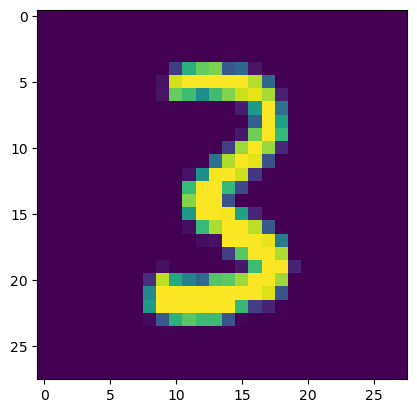

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.imshow(xb[0].view(28, 28)); yb[0]

In [ ]:
model, opt = get_model()

In [ ]:
def fit():
  for epoch in range(epochs):
    for xb, yb in trn_dl:
      preds = model(xb)
      loss = loss_func(preds, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()
    report(loss, preds, yb)

In [ ]:
fit()

0.24, 0.94
0.15, 0.94
0.09, 1.00


In [ ]:
loss_func(model(xb), yb), accuracy(model(xb), yb)

(tensor(0.06, grad_fn=<NllLossBackward0>), tensor(0.98))

### Random Sampling

Sampling from the training set should be random, but not from the validation set.

In [ ]:
import random

Signature: random.shuffle(x, random=None)
Docstring:
Shuffle list x in place, and return None.

Optional argument random is a 0-argument function returning a
random float in [0.0, 1.0); if it is the default None, the
standard random.random will be used.
File:      ~/mambaforge/envs/default/lib/python3.10/random.py
Type:      method

In [ ]:
?random.shuffle

In [ ]:
class Sampler():
  def __init__(self, ds, shuffle=False): self.n, self.shuffle = len(ds), shuffle
  def __iter__(self):
    res = list(range(self.n))
    if self.shuffle: random.shuffle(res)
    return iter(res) 
    # for samp in range(0, n): yield shuffle(samp)

In [ ]:
ss = Sampler(trn_ds); ss

<__main__.Sampler>

In [ ]:
# This doesn't work because __iter__ isn't being called. __iter__ only gets called when we wrap the class with iter().
try: next(ss)
except: print('did not work')

did not work


In [ ]:
it = iter(ss)
for o in range(5): print(next(it))

0
1
2
3
4


In [ ]:
from itertools import islice

[0, 1, 2, 3, 4]

In [ ]:
list(islice(ss, 5))

In [ ]:
ss = Sampler(trn_ds, shuffle=True)
list(islice(ss, 5))

[14455, 28729, 4481, 1537, 220]

In [ ]:
from fastcore.all import *

In [ ]:
class BatchSampler():
  def __init__(self, sampler, bs, drop_last=False): store_attr()
  def __iter__(self): yield from chunked(iter(self.sampler), self.bs, drop_last=self.drop_last)

In [ ]:
batches = BatchSampler(ss, 4)
list(islice(batches, 5))

[[29101, 12004, 7800, 41667],
 [11511, 9520, 41994, 3466],
 [35643, 23112, 5022, 48859],
 [3547, 36552, 5050, 48237],
 [45039, 1143, 17595, 32287]]

In [ ]:
def collate(b):
  xs, ys = zip(*b)
  return torch.stack(xs), torch.stack(ys)

In [ ]:
class DataLoader():
  def __init__(self, ds, batches, collate_fn=collate): store_attr()
  def __iter__(self): yield from (self.collate_fn(self.ds[i] for i in b) for b in self.batches)

In [ ]:
trn_samp = BatchSampler(Sampler(trn_ds, shuffle=True), bs)
vld_samp = BatchSampler(Sampler(vld_ds, shuffle=False), bs)

In [ ]:
o = next(iter(vld_samp)); o

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63]

In [ ]:
p = [vld_ds[i] for i in o]; p, len(p)

([(tensor([0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
           0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
           0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
           0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
           0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
           0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.18, 0.62, 0.76, 0.80, 0.28, 0.34, 0.05, 0.00, 0.00, 0.00,
           0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.05, 0.93, 0.99, 0.99, 0.99,

In [ ]:
xs, ys = zip(*p); ys

(tensor(3),
 tensor(8),
 tensor(6),
 tensor(9),
 tensor(6),
 tensor(4),
 tensor(5),
 tensor(3),
 tensor(8),
 tensor(4),
 tensor(5),
 tensor(2),
 tensor(3),
 tensor(8),
 tensor(4),
 tensor(8),
 tensor(1),
 tensor(5),
 tensor(0),
 tensor(5),
 tensor(9),
 tensor(7),
 tensor(4),
 tensor(1),
 tensor(0),
 tensor(3),
 tensor(0),
 tensor(6),
 tensor(2),
 tensor(9),
 tensor(9),
 tensor(4),
 tensor(1),
 tensor(3),
 tensor(6),
 tensor(8),
 tensor(0),
 tensor(7),
 tensor(7),
 tensor(6),
 tensor(8),
 tensor(9),
 tensor(0),
 tensor(3),
 tensor(8),
 tensor(3),
 tensor(7),
 tensor(7),
 tensor(8),
 tensor(4),
 tensor(4),
 tensor(1),
 tensor(2),
 tensor(9),
 tensor(8),
 tensor(1),
 tensor(1),
 tensor(0),
 tensor(6),
 tensor(6),
 tensor(5),
 tensor(0),
 tensor(1),
 tensor(1))

In [ ]:
torch.stack(ys)

tensor([3, 8, 6, 9, 6, 4, 5, 3, 8, 4, 5, 2, 3, 8, 4, 8, 1, 5, 0, 5, 9, 7, 4, 1, 0, 3, 0, 6, 2, 9, 9, 4, 1, 3, 6, 8, 0, 7, 7, 6, 8, 9, 0, 3,
        8, 3, 7, 7, 8, 4, 4, 1, 2, 9, 8, 1, 1, 0, 6, 6, 5, 0, 1, 1])

In [ ]:
trn_samp = BatchSampler(Sampler(trn_ds, shuffle=True), bs)
vld_samp = BatchSampler(Sampler(vld_ds, shuffle=False), bs)

In [ ]:
trn_dl = DataLoader(trn_ds, batches=trn_samp)
vld_dl = DataLoader(vld_ds, batches=vld_samp)

tensor(3)

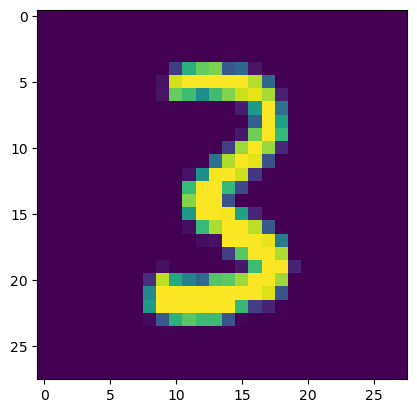

In [ ]:
xb, yb = next(iter(vld_dl))
plt.imshow(xb[0].view(28, 28))
yb[0]

In [ ]:
xb.shape, yb.shape

(torch.Size([64, 784]), torch.Size([64]))

In [ ]:
model, opt = get_model()

In [ ]:
fit()

0.21, 0.94
0.05, 1.00
0.14, 0.94


In [ ]:
??fit

Signature: fit()
Docstring: <no docstring>
Source:   
def fit():
  for epoch in range(epochs):
    for xb, yb in trn_dl:
      preds = model(xb)
      loss = loss_func(preds, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()
    report(loss, preds, yb)
File:      /var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_99469/557523459.py
Type:      function

### Multiprocessing DataLoader

In [ ]:
trn_ds[[3, 6, 8, 1]]

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([1, 1, 1, 0]))

In [ ]:
??trn_ds.__getitem__

Signature: trn_ds.__getitem__(i)
Docstring: <no docstring>
Source:      def __getitem__(self, i): return self.x[i], self.y[i]
File:      /var/folders/fy/vg316qk1001227svr6d4d8l40000gn/T/ipykernel_99469/694427655.py
Type:      method

In [ ]:
trn_ds.__getitem__([3, 6, 8, 1])

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([1, 1, 1, 0]))

In [ ]:
len(list(map(trn_ds.__getitem__, ([3, 6], [8, 1]))))

2

In [ ]:
for o in map(trn_ds.__getitem__, ([3, 6], [8, 1])): print(o)

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), tensor([1, 1]))
(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), tensor([1, 0]))


In [ ]:
import torch.multiprocessing as mp

In [ ]:
class DataLoader():
  def __init__(self, ds, batches, n_workers=1, collate_fn=collate): store_attr()
  def __iter__(self):
    with mp.Pool(self.n_workers) as ex: yield from ex.map(self.ds.__getitem__, iter(self.batches))

In [ ]:
# TODO: Perform a %%timeit to perform a comparison.
trn_dl = DataLoader(trn_ds, batches=trn_samp, n_workers=2)
it = iter(trn_dl)

In [ ]:
xb, yb = next(it); xb.shape, yb.shape

(torch.Size([64, 784]), torch.Size([64]))

In [ ]:
#| export
from torch.utils.data import DataLoader, SequentialSampler, RandomSampler, BatchSampler

Init signature:
BatchSampler(
    sampler: Union[torch.utils.data.sampler.Sampler[int], Iterable[int]],
    batch_size: int,
    drop_last: bool,
) -> None
Docstring:     
Wraps another sampler to yield a mini-batch of indices.

Args:
    sampler (Sampler or Iterable): Base sampler. Can be any iterable object
    batch_size (int): Size of mini-batch.
    drop_last (bool): If ``True``, the sampler will drop the last batch if
        its size would be less than ``batch_size``

Example:
    >>> list(BatchSampler(SequentialSampler(range(10)), batch_size=3, drop_last=False))
    [[0, 1, 2], [3, 4, 5], [6, 7, 8], [9]]
    >>> list(BatchSampler(SequentialSampler(range(10)), batch_size=3, drop_last=True))
    [[0, 1, 2], [3, 4, 5], [6, 7, 8]]
File:           ~/mambaforge/envs/default/lib/python3.10/site-packages/torch/utils/data/sampler.py
Type:           type
Subclasses:     

In [ ]:
?BatchSampler

In [ ]:
?RandomSampler

Init signature:
RandomSampler(
    data_source: Sized,
    replacement: bool = False,
    num_samples: Optional[int] = None,
    generator=None,
) -> None
Docstring:     
Samples elements randomly. If without replacement, then sample from a shuffled dataset.
If with replacement, then user can specify :attr:`num_samples` to draw.

Args:
    data_source (Dataset): dataset to sample from
    replacement (bool): samples are drawn on-demand with replacement if ``True``, default=``False``
    num_samples (int): number of samples to draw, default=`len(dataset)`.
    generator (Generator): Generator used in sampling.
File:           ~/mambaforge/envs/default/lib/python3.10/site-packages/torch/utils/data/sampler.py
Type:           type
Subclasses:     

In [ ]:
trn_samp = BatchSampler(    RandomSampler(trn_ds), bs, drop_last=False)
vld_samp = BatchSampler(SequentialSampler(vld_ds), bs, drop_last=False)

In [ ]:
?DataLoader

Init signature:
DataLoader(
    dataset: torch.utils.data.dataset.Dataset[+T_co],
    batch_size: Optional[int] = 1,
    shuffle: Optional[bool] = None,
    sampler: Union[torch.utils.data.sampler.Sampler, Iterable, NoneType] = None,
    batch_sampler: Union[torch.utils.data.sampler.Sampler[Sequence], Iterable[Sequence], NoneType] = None,
    num_workers: int = 0,
    collate_fn: Optional[Callable[[List[~T]], Any]] = None,
    pin_memory: bool = False,
    drop_last: bool = False,
    timeout: float = 0,
    worker_init_fn: Optional[Callable[[int], NoneType]] = None,
    multiprocessing_context=None,
    generator=None,
    *,
    prefetch_factor: Optional[int] = None,
    persistent_workers: bool = False,
    pin_memory_device: str = '',
)
Docstring:     
Data loader. Combines a dataset and a sampler, and provides an iterable over
the given dataset.

The :class:`~torch.utils.data.DataLoader` supports both map-style and
iterable-style datasets with single- or multi-process loading, cus

In [ ]:
trn_dl = DataLoader(trn_ds, batch_sampler=trn_samp, collate_fn=collate)
vld_dl = DataLoader(vld_dl, batch_sampler=vld_samp, collate_fn=collate)

In [ ]:
model, opt = get_model()
fit()
loss_func(model(xb), yb), accuracy(model(xb), yb)

0.28, 0.88
0.06, 1.00
0.07, 1.00


(tensor(0.11, grad_fn=<NllLossBackward0>), tensor(0.95))

Alternatively, we can let PyTorch autogenerate the BatchSampler.

In [ ]:
trn_dl = DataLoader(trn_ds, bs, sampler=    RandomSampler(trn_ds), collate_fn=collate)
vld_dl = DataLoader(vld_ds, bs, sampler=SequentialSampler(trn_ds), collate_fn=collate)

Alternatively, we can let it autogenerate the Sequantial/RandomSamplers too.

In [ ]:
trn_dl = DataLoader(trn_ds, bs, shuffle=True, drop_last=True, num_workers=2)
vld_dl = DataLoader(vld_ds, bs, shuffle=False, num_workers=2)

In [ ]:
model, opt = get_model(); fit()

0.26, 0.94
0.07, 0.98
0.14, 0.95


In [ ]:
loss_func(model(xb), yb), accuracy(model(xb), yb)

(tensor(0.09, grad_fn=<NllLossBackward0>), tensor(0.98))

In [ ]:
# fit()

As out dataset already knows how to sample a batch of indices all at once, we can actually skip the `batch_sampler` and `collate_fn` entirely.

In [ ]:
trn_ds[[4, 6, 7]]

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([9, 1, 3]))

In [ ]:
trn_dl = DataLoader(trn_ds, sampler=trn_samp)
vld_dl = DataLoader(vld_ds, sampler=vld_samp)

In [ ]:
xb, yb = next(iter(trn_dl)); xb.shape, yb.shape

(torch.Size([1, 64, 784]), torch.Size([1, 64]))

## Validation

In [ ]:
?model.train

Signature: model.train(mode: bool = True) -> ~T
Docstring:
Sets the module in training mode.

This has any effect only on certain modules. See documentations of
particular modules for details of their behaviors in training/evaluation
mode, if they are affected, e.g. :class:`Dropout`, :class:`BatchNorm`,
etc.

Args:
    mode (bool): whether to set training mode (``True``) or evaluation
                 mode (``False``). Default: ``True``.

Returns:
    Module: self
File:      ~/mambaforge/envs/default/lib/python3.10/site-packages/torch/nn/modules/module.py
Type:      method

In [ ]:
#| export
def fit(epochs, model, loss_func, opt, trn_dl, vld_dl):
  for epoch in range(epochs):
    model.train()
    for xb, yb in trn_dl:
      preds = model(xb)
      loss = loss_func(preds, yb)
      loss.backward()
      opt.step()
      opt.zero_grad()
      report(loss, preds, yb)
    
    model.eval()
    with torch.no_grad():
      tot_loss, tot_acc, count = 0., 0., 0
      for xb, yb in vld_dl:
        preds = model(xb)
        n = len(xb)
        count += n
        tot_loss += loss_func(preds, yb).item() * n
        tot_acc  += accuracy (preds, yb).item() * n
    print(epoch, tot_loss/count, tot_acc/count)
  return tot_loss/count, tot_acc/count


In [ ]:
#| export
def get_dls(trn_ds, vld_ds, bs, **kwargs):
  return (DataLoader(trn_ds, batch_size=bs, shuffle=True, **kwargs),
          DataLoader(vld_ds, batch_size=bs*2, **kwargs))

In [ ]:
trn_dl, vld_dl = get_dls(trn_ds, vld_ds, bs)
model, opt = get_model()

In [ ]:
%time loss, acc = fit(5, model, loss_func, opt, trn_dl, vld_dl)

2.30, 0.19
2.28, 0.16
2.20, 0.34
2.04, 0.34
1.99, 0.34
1.89, 0.45
1.87, 0.42
1.69, 0.55
1.78, 0.52
1.48, 0.66
1.18, 0.67
1.26, 0.61
1.33, 0.52
1.33, 0.55
1.13, 0.61
0.90, 0.77
1.14, 0.64
1.21, 0.55
1.63, 0.50
1.55, 0.55
1.00, 0.69
1.08, 0.66
0.85, 0.75
0.90, 0.75
1.29, 0.56
0.99, 0.62
0.89, 0.66
0.80, 0.75
0.65, 0.80
0.89, 0.69
0.52, 0.92
0.75, 0.73
0.62, 0.77
0.68, 0.84
0.61, 0.84
0.53, 0.86
0.63, 0.78
0.64, 0.86
0.69, 0.80
0.61, 0.81
0.66, 0.78
0.43, 0.91
0.60, 0.86
0.58, 0.77
0.41, 0.84
0.54, 0.86
0.56, 0.83
0.53, 0.81
0.28, 0.92
0.59, 0.81
0.47, 0.83
0.61, 0.80
0.97, 0.77
0.77, 0.70
0.76, 0.70
0.42, 0.88
0.65, 0.83
0.67, 0.84
0.49, 0.89
0.54, 0.81
0.36, 0.91
0.68, 0.81
0.43, 0.89
0.37, 0.84
0.54, 0.84
0.69, 0.81
0.52, 0.86
0.46, 0.81
0.42, 0.94
0.44, 0.88
0.40, 0.84
0.50, 0.86
0.70, 0.78
0.78, 0.75
0.50, 0.83
0.88, 0.70
0.74, 0.70
0.71, 0.77
0.67, 0.80
0.51, 0.84
0.48, 0.88
0.66, 0.80
0.43, 0.86
0.67, 0.78
0.50, 0.89
0.42, 0.89
0.29, 0.94
0.62, 0.81
0.54, 0.84
0.32, 0.91
0.34, 0.86

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()